<a href="https://colab.research.google.com/github/Hugocruz23/data-analytics-portfolio/blob/main/Proyecto_Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/Hugocruz23/data-analytics-portfolio/refs/heads/main/projects%20/sales-forecast/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px

In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors = "coerce")


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
data = data.dropna()

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
def value(x):
    if x == "Yes":
      return(1)
    elif x == "No":
      return(0)
    elif x == "Female":
      return(1)
    elif x == "Male":
      return(0)
    else:
      return(x)
    return

In [10]:
for y in data.columns:
  data[y] = data[y].apply(value)

In [11]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,0,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,0,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,1,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,0,1,1,24,1,1,DSL,1,...,1,1,1,1,One year,1,Mailed check,84.80,1990.50,0
7039,2234-XADUH,1,0,1,1,72,1,1,Fiber optic,0,...,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,1,0,1,1,11,0,No phone service,DSL,1,...,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,0,1,1,0,4,1,1,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.60,1


In [12]:
data.describe(include = "all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7032,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.0,7032,7032.0,...,7032.0,7032.0,7032.0,7032.0,7032,7032.000000,7032,7032.000000,7032.000000,7032.000000
unique,7032,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3,3.0,...,3.0,3.0,3.0,3.0,3,NaN,4,NaN,NaN,NaN
top,3186-AJIEK,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Fiber optic,0.0,...,0.0,0.0,0.0,0.0,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,3385.0,3096,3497.0,...,3094.0,3472.0,2809.0,2781.0,3875,NaN,2365,NaN,NaN,NaN
mean,NaN,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.592719,NaN,64.798208,2283.300441,0.265785
std,NaN,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.491363,NaN,30.085974,2266.771362,0.441782
min,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,18.800000,0.000000
25%,NaN,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.587500,401.450000,0.000000
50%,NaN,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.350000,1397.475000,0.000000
75%,NaN,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.862500,3794.737500,1.000000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

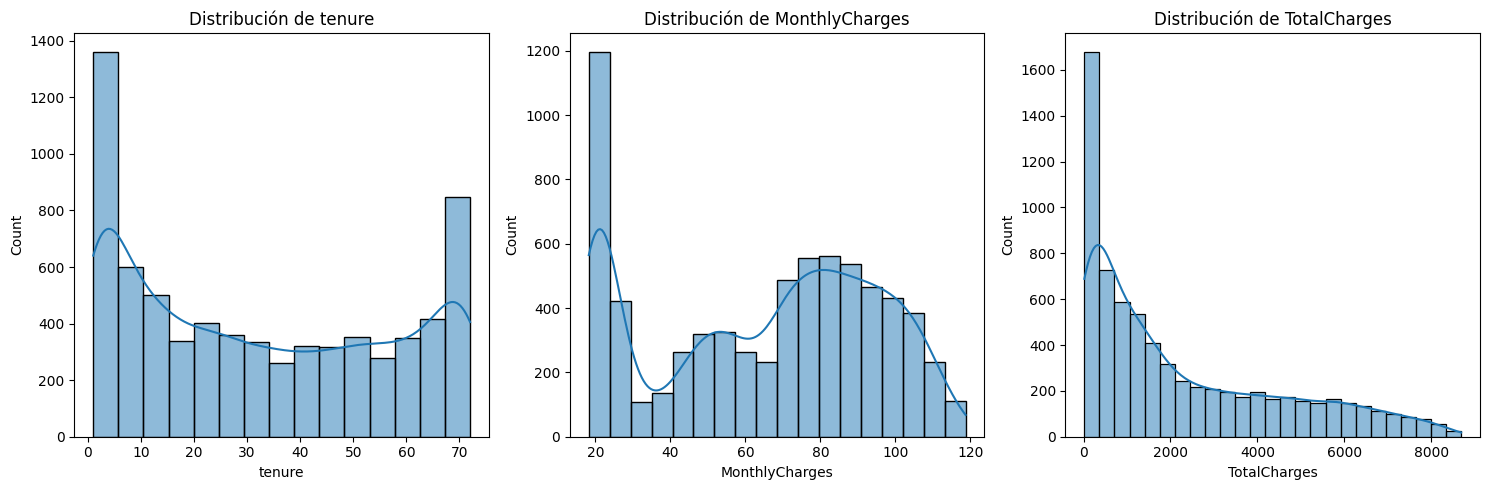

In [14]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

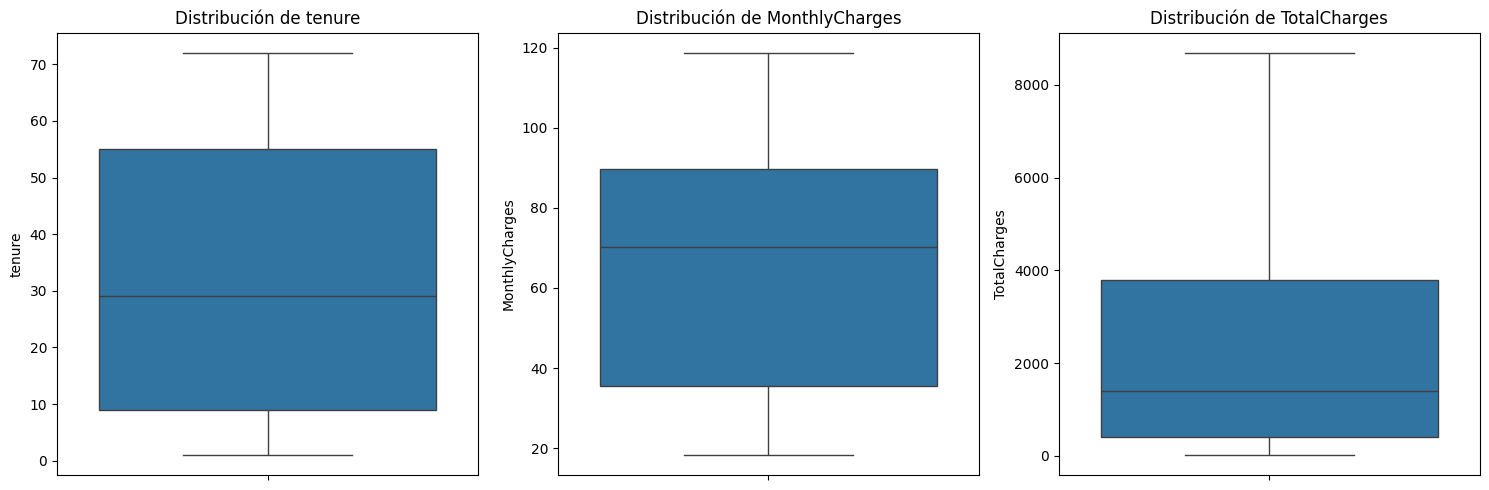

In [15]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data[col])
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

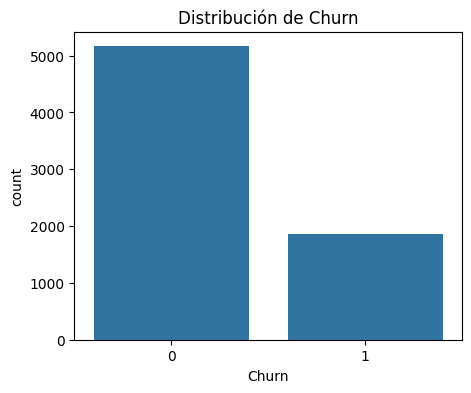

,proportion
Churn,
0,73.421502
1,26.578498


In [16]:
plt.figure(figsize=(5,4))
sns.countplot(data = data, x='Churn')
plt.title('Distribución de Churn')
plt.show()

data['Churn'].value_counts(normalize=True) * 100

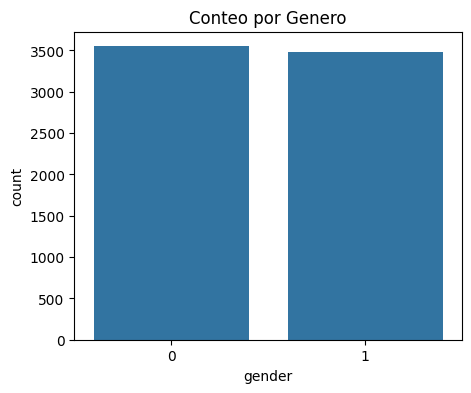

,proportion
gender,
0,50.469283
1,49.530717


In [17]:
plt.figure(figsize= (5,4))
sns.countplot(data = data, x = "gender")
plt.title("Conteo por Genero")
plt.show()

data["gender"].value_counts(normalize = True) * 100

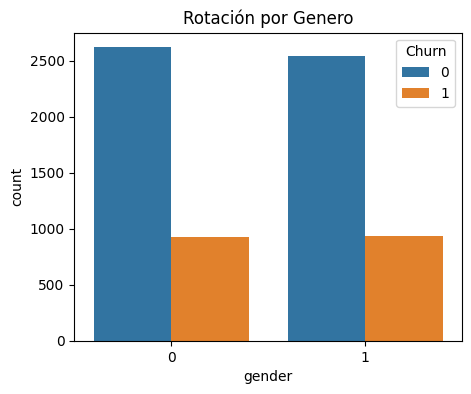

In [18]:
plt.figure(figsize= (5,4))
sns.countplot(data = data, x = "gender", hue= "Churn")
plt.title("Rotación por Genero")
plt.show()

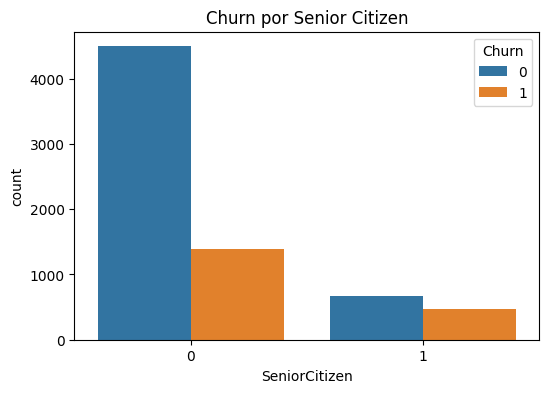

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='SeniorCitizen', hue='Churn')
plt.title('Churn por Senior Citizen')
plt.show()

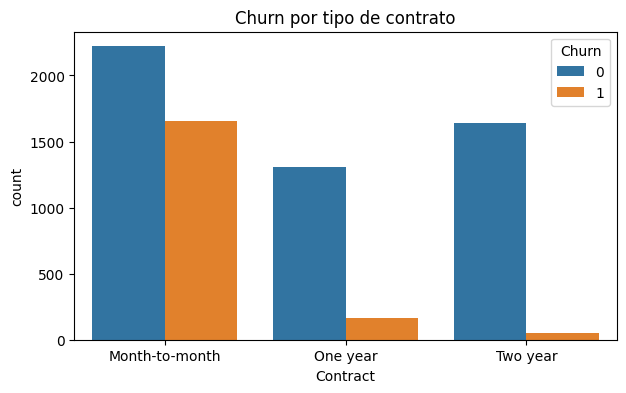

,Churn
Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


In [20]:
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='Contract', hue='Churn')
plt.title('Churn por tipo de contrato')
plt.show()

data.groupby('Contract')['Churn'].mean()

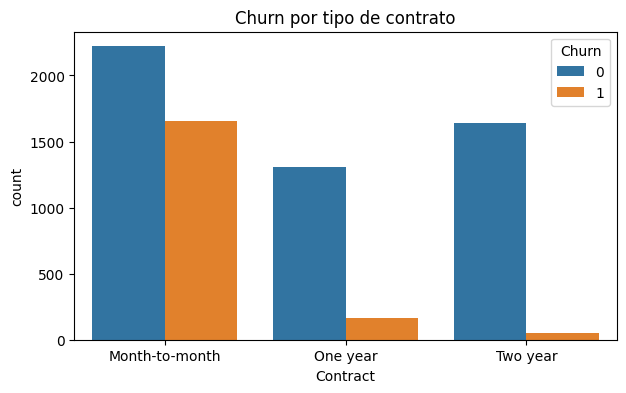

,Churn
Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


In [21]:
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='Contract', hue='Churn')
plt.title('Churn por tipo de contrato')
plt.show()

data.groupby('Contract')['Churn'].mean()

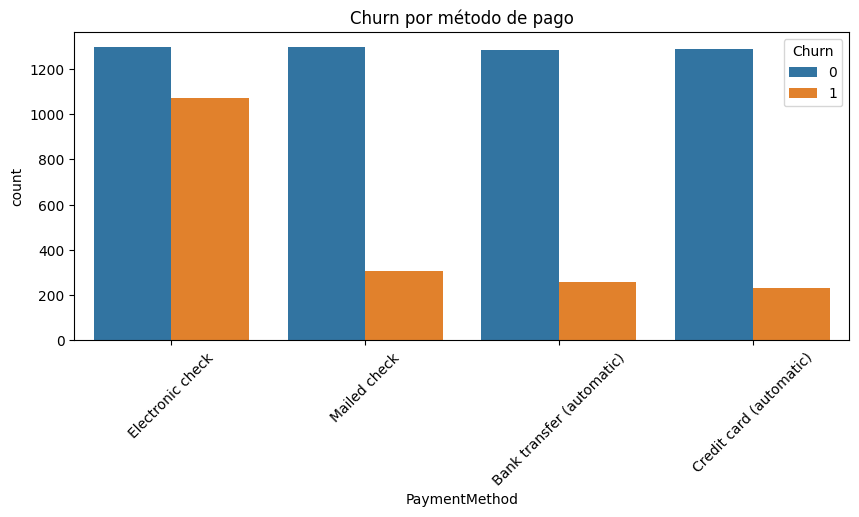

,Churn
PaymentMethod,
Bank transfer (automatic),0.167315
Credit card (automatic),0.152531
Electronic check,0.452854
Mailed check,0.192020


In [22]:
plt.figure(figsize=(10,4))
sns.countplot(data=data, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.title('Churn por método de pago')
plt.show()

data.groupby('PaymentMethod')['Churn'].mean()

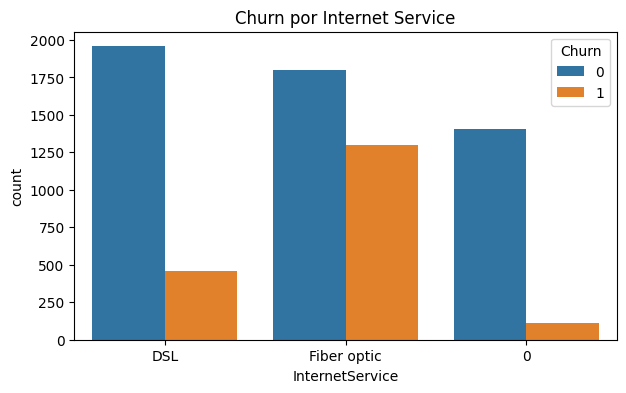

In [23]:
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='InternetService', hue='Churn')
plt.title('Churn por Internet Service')
plt.show()

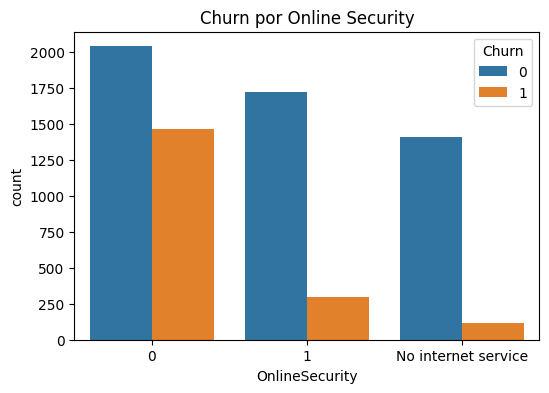

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='OnlineSecurity', hue='Churn')
plt.title('Churn por Online Security')
plt.show()

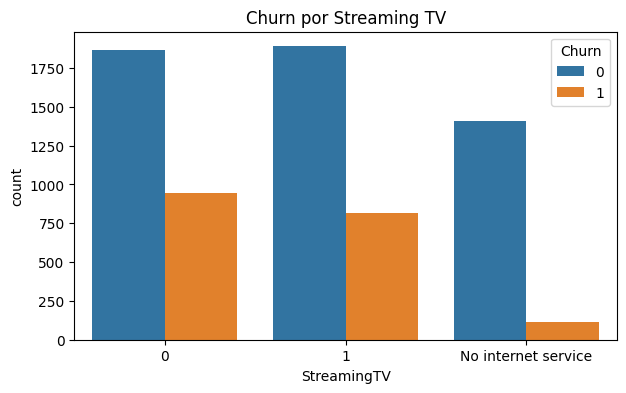

In [25]:
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='StreamingTV', hue='Churn')
plt.title('Churn por Streaming TV')
plt.show()

/tmp/ipykernel_4284/2090345674.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[data['Churn'] == 1]['MonthlyCharges'], label='Churn', shade=True)
/tmp/ipykernel_4284/2090345674.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[data['Churn'] == 0]['MonthlyCharges'], label='No Churn', shade=True)


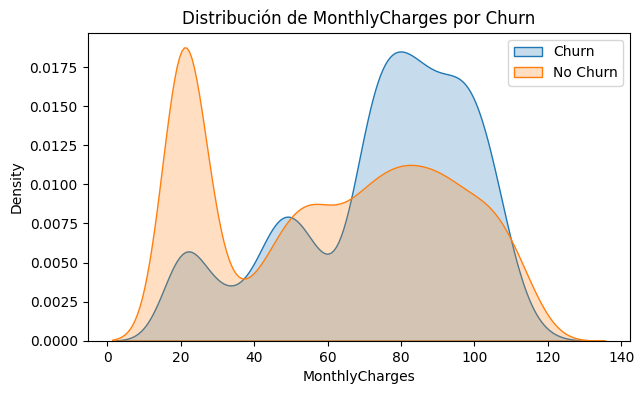

In [26]:
##Relación entre carga mensual y churn
#Este análisis muestra si clientes que pagan más abandonan más.
plt.figure(figsize=(7,4))
sns.kdeplot(data[data['Churn'] == 1]['MonthlyCharges'], label='Churn', shade=True)
sns.kdeplot(data[data['Churn'] == 0]['MonthlyCharges'], label='No Churn', shade=True)
plt.title('Distribución de MonthlyCharges por Churn')
plt.legend()
plt.show()

/tmp/ipykernel_4284/2913723577.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[data['Churn'] == 1]['tenure'], label='Churn', shade=True)
/tmp/ipykernel_4284/2913723577.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[data['Churn'] == 0]['tenure'], label='No Churn', shade=True)


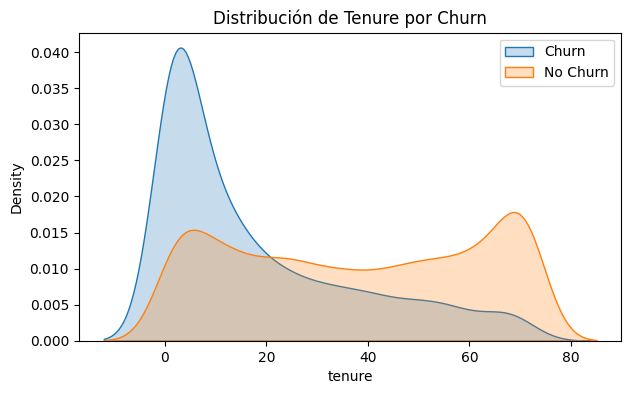

In [27]:
plt.figure(figsize=(7,4))
sns.kdeplot(data[data['Churn'] == 1]['tenure'], label='Churn', shade=True)
sns.kdeplot(data[data['Churn'] == 0]['tenure'], label='No Churn', shade=True)
plt.title('Distribución de Tenure por Churn')
plt.legend()
plt.show()

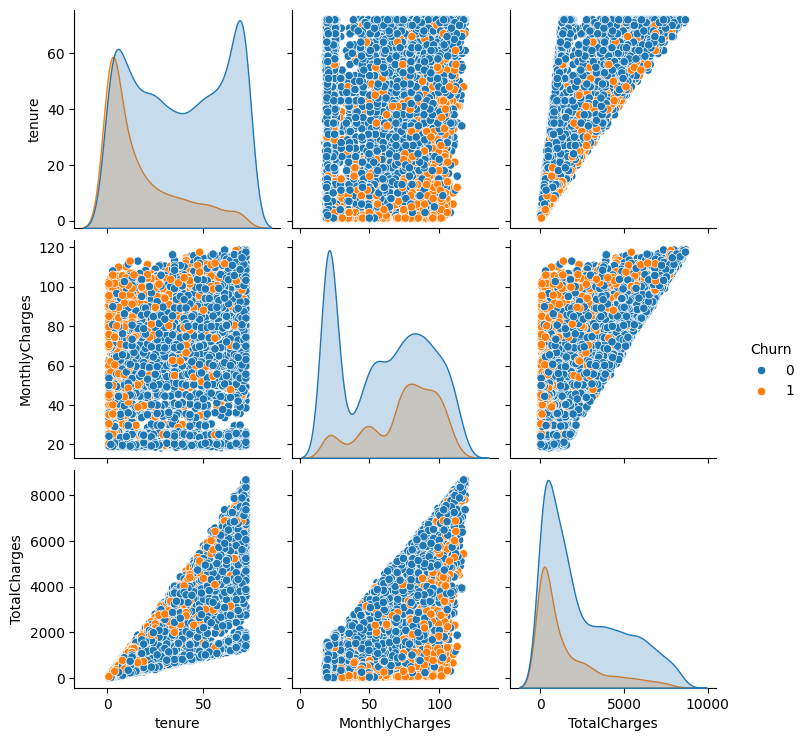

In [28]:
sns.pairplot(data[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn')

In [29]:
##FASE 3
#Transformar el dataset original en uno más inteligente, creando variables que:
#Expliquen mejor el churn
#Aporten valor de negocio
#Permitan análisis más profundos
#Preparen el dataset para modelos (aunque no los hagas aún)

In [30]:
#Vamos a monstrar nuevamente las estadisticas de los datos
data.describe(include = "all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7032,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.0,7032,7032.0,...,7032.0,7032.0,7032.0,7032.0,7032,7032.000000,7032,7032.000000,7032.000000,7032.000000
unique,7032,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3,3.0,...,3.0,3.0,3.0,3.0,3,NaN,4,NaN,NaN,NaN
top,3186-AJIEK,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Fiber optic,0.0,...,0.0,0.0,0.0,0.0,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,3385.0,3096,3497.0,...,3094.0,3472.0,2809.0,2781.0,3875,NaN,2365,NaN,NaN,NaN
mean,NaN,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.592719,NaN,64.798208,2283.300441,0.265785
std,NaN,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.491363,NaN,30.085974,2266.771362,0.441782
min,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,18.800000,0.000000
25%,NaN,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.587500,401.450000,0.000000
50%,NaN,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.350000,1397.475000,0.000000
75%,NaN,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.862500,3794.737500,1.000000


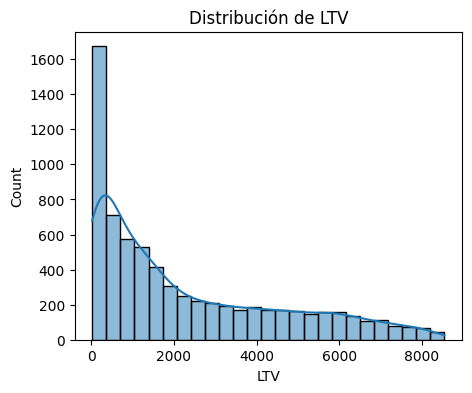

In [31]:
#Crear CLV (Customer Lifetime Value básico) y compararlo con 'churn'
data['LTV'] = data["tenure"] * data["MonthlyCharges"]
#Monstremos la distribución de los datos
plt.figure(figsize=(5,4))
sns.histplot(data['LTV'], kde=True)
plt.title('Distribución de LTV')
plt.show()

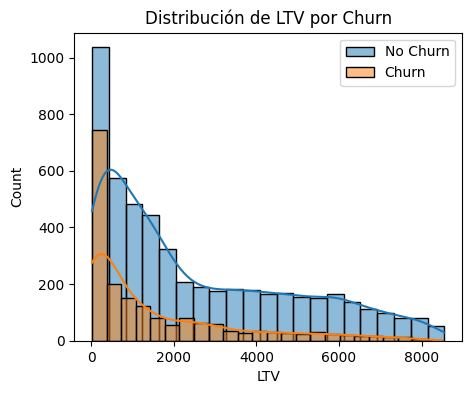

In [32]:
#Ahora vamos a compararlo con 'churn'
plt.figure(figsize=(5,4))
sns.histplot(data[data['Churn'] == 0]['LTV'], label='No Churn', kde=True) # 0 Que no nos ha abandonado
sns.histplot(data[data['Churn'] == 1]['LTV'], label='Churn', kde=True) # 1 que si nos ha abandonado
plt.legend()
plt.title('Distribución de LTV por Churn')
plt.show()

In [33]:
#Crear ingreso promedio mensual real
data['AvgMonthlySpend'] = data['TotalCharges'] / data['tenure']

Text(0.5, 1.0, 'Distribución de AvgMonthlySpend ')

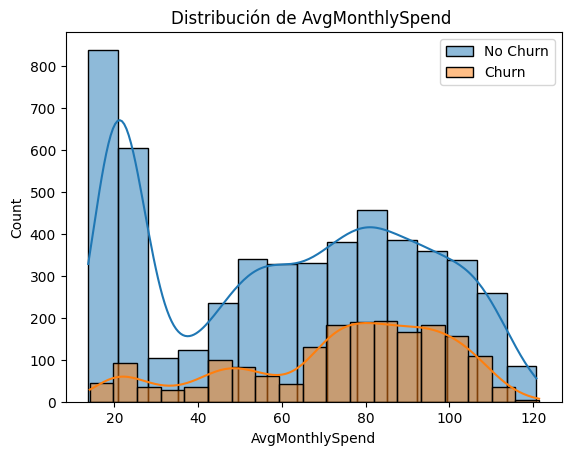

In [34]:
#Grafiquemos la distribución de los promedios
sns.histplot(data[data['Churn'] == 0]['AvgMonthlySpend'], label='No Churn', kde=True) # 0 Que no nos ha abandonado
sns.histplot(data[data['Churn'] == 1]['AvgMonthlySpend'], label='Churn', kde=True) # 1 Que no nos ha abandonado
plt.legend()
plt.title('Distribución de AvgMonthlySpend ')

In [35]:
#Sumar el total de servicios contratados
#Esto nos dara la cantidad de servicios que se contratan en total

In [36]:
data = pd.get_dummies(data, columns= ['InternetService'], dtype= int)

In [37]:
#Vamos a filtrar las columnas de los servicios para despues sumarlos, los guardamos en una variable llamada 'data_service'
mask = data[['OnlineSecurity',
'PhoneService',
'OnlineBackup',
'DeviceProtection',
'Churn',
'TechSupport'  ,
'StreamingTV',
'StreamingMovies']] == "No internet service"

data_service = data[['OnlineSecurity',
'OnlineBackup',
'PhoneService',
'DeviceProtection',
'TechSupport',
'Churn',
'StreamingTV',
'StreamingMovies']][~mask]

In [38]:
data_service['TotalServices'] = data_service['PhoneService']+ data_service['OnlineSecurity'] + data_service['OnlineBackup'] + data_service['DeviceProtection'] + data_service['TechSupport'] + data_service['StreamingTV'] + data_service['StreamingMovies']

In [39]:
#Revisamos si se ejecutaron correctamente las variables de los servicios
data_service.shape


(7032, 9)

<Axes: xlabel='TotalServices', ylabel='count'>

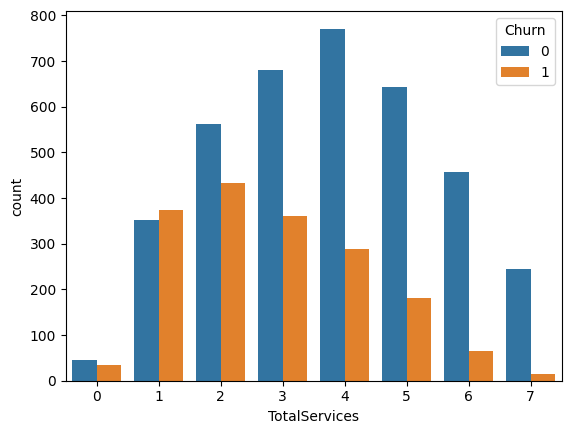

In [40]:
#Comparamos churn con el numero total de servicios
#Esto para conocer si entre mas servicios o menos servicios las personas abandonan o peramnecen con el servicio
sns.countplot(data=data_service, x='TotalServices', hue='Churn')


In [41]:
#Crear segmentación de clientes (MUY IMPORTANTE), definiendo una varibale llamada 'tenure'
def tenure(x):
    if x <= 12 :
      return("Low tenure")
    elif x > 12 and x < 32:
      return('medium tenure')
    elif x >= 32:
      return('high tenure')
data["level tenure"] = data["tenure"].apply(tenure)

In [42]:
#Utilizamos el rango intercuantilico para poder profseguir con la clasificación de nuestros datos
Q1 = data["TotalCharges"].quantile(0.25)
Q3 = data["TotalCharges"].quantile(0.75)
IQR = Q3 - Q1
Upper_limit = IQR + Q3 * 1.5
Low_limit = IQR + Q1 * 1.5
Q1

np.float64(401.45)

In [43]:
#Ahora clasificamos por gasto
def spend(y):
    if y <= Q1 :
      return("Low spend")
    elif y > Q1 and y < Q3:
      return('Medium spend')
    elif y >= Q3:
      return('High spend')
    return
data['level spend'] = data["TotalCharges"].apply(spend)

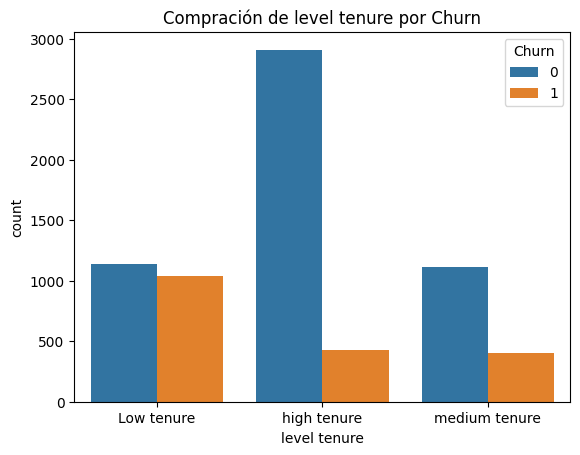

In [44]:
#Ahora vamos a comparar la clasificación de 'level tenure' por 'churn
sns.countplot(data = data, x = 'level tenure',  hue= 'Churn')
plt.title('Compración de level tenure por Churn')
plt.show(
)

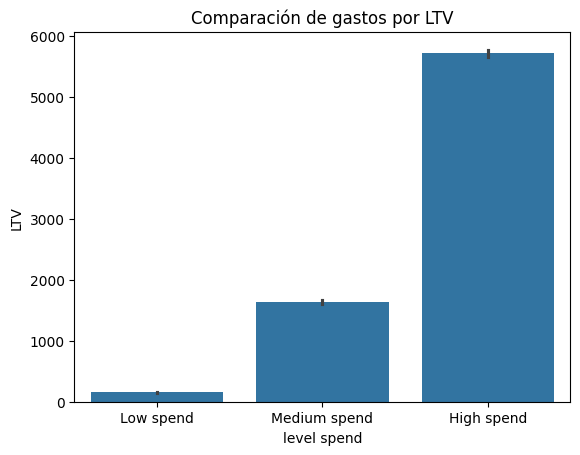

In [45]:
#Ahora vamos a comparar la clasificación de 'level spend' por 'churn
sns.barplot( data = data, x = 'level spend', y = 'LTV' )
plt.title('Comparación de gastos por LTV')
plt.show(
)

In [46]:
## Crear variable de riesgo (AVANZADO)
#Obsevamos nuevamente nuestro conjunto de datos
data = data.drop(['InternetService_0'], axis  = 1 )

In [47]:
#Unimos la tabla de los totales de los servicios('data_service') con nuestra tabla principal
data = pd.concat([data_service['TotalServices'], data], axis = 1)

In [48]:
#Verificamos las colunmnas y su union
data[['OnlineSecurity',
'PhoneService',
'OnlineBackup',
'DeviceProtection',
'TechSupport'  ,
'StreamingTV',
'StreamingMovies','TotalServices','InternetService_DSL','InternetService_Fiber optic']].head(20)

,OnlineSecurity,PhoneService,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalServices,InternetService_DSL,InternetService_Fiber optic
0,0,0,1,0,0,0,0,1,1,0
1,1,1,0,1,0,0,0,3,1,0
2,1,1,1,0,0,0,0,3,1,0
3,1,0,0,1,1,0,0,3,1,0
4,0,1,0,0,0,0,0,1,0,1
5,0,1,0,1,0,1,1,4,0,1
6,0,1,1,0,0,1,0,3,0,1
7,1,0,0,0,0,0,0,1,1,0
8,0,1,0,1,1,1,1,5,0,1
9,1,1,1,0,0,0,0,3,1,0


In [49]:
#Continuamos con la creación de nuestra variable de riesgo
#Primero vamos a clasificar las variables categoricas necesarias

In [50]:
data['TotalServices'] = data['TotalServices'] +	data['InternetService_DSL']+	data['InternetService_Fiber optic']

In [51]:
#Vamos a convertir los valores nulos en 1, esto por el hecho de las personas que solamente contrataron servicio de telefono, esto equivale a 1
data['TotalServices'].fillna(1 ,inplace = True)

/tmp/ipykernel_4284/538956892.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalServices'].fillna(1 ,inplace = True)
/tmp/ipykernel_4284/538956892.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['TotalServices'].fillna(1 ,inplace = True)


In [52]:
#Conmenzamos con la creación de variables de conversión en una escala de 1 a 3(1 como minimo y 3 como maximo), esto se aplica para todas las variables a covertir
#Creamos nuestra primera conversión para nuestra variable de riesgo
def risk(variable_1):
    if variable_1 == 'Low tenure':
      return(1)
    elif variable_1 == 'medium tenure':
      return(2)
    elif variable_1 == 'high tenure':
      return(3)
    return
data['level_tenure_convert'] = data['level tenure'].apply(risk)

data.head()

,TotalServices,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,LTV,AvgMonthlySpend,InternetService_DSL,InternetService_Fiber optic,level tenure,level spend,level_tenure_convert
0,2,7590-VHVEG,1,0,1,0,1,0,No phone service,0,...,29.85,29.85,0,29.85,29.850000,1,0,Low tenure,Low spend,1
1,4,5575-GNVDE,0,0,0,0,34,1,0,1,...,56.95,1889.50,0,1936.30,55.573529,1,0,high tenure,Medium spend,3
2,4,3668-QPYBK,0,0,0,0,2,1,0,1,...,53.85,108.15,1,107.70,54.075000,1,0,Low tenure,Low spend,1
3,4,7795-CFOCW,0,0,0,0,45,0,No phone service,1,...,42.30,1840.75,0,1903.50,40.905556,1,0,high tenure,Medium spend,3
4,2,9237-HQITU,1,0,0,0,2,1,0,0,...,70.70,151.65,1,141.40,75.825000,0,1,Low tenure,Low spend,1


In [53]:
#Creamos nuestra segunda conversión para nuestra variable de riesgo
def risk_1(variable_2):
    if variable_2 == 'Month-to-month':
      return(1)
    elif variable_2 == 'One year':
      return(2)
    elif variable_2 == 'Two year':
      return(3)
    return
data['Contract_level'] = data['Contract'].apply(risk_1)

data.head()

,TotalServices,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,...,TotalCharges,Churn,LTV,AvgMonthlySpend,InternetService_DSL,InternetService_Fiber optic,level tenure,level spend,level_tenure_convert,Contract_level
0,2,7590-VHVEG,1,0,1,0,1,0,No phone service,0,...,29.85,0,29.85,29.850000,1,0,Low tenure,Low spend,1,1
1,4,5575-GNVDE,0,0,0,0,34,1,0,1,...,1889.50,0,1936.30,55.573529,1,0,high tenure,Medium spend,3,2
2,4,3668-QPYBK,0,0,0,0,2,1,0,1,...,108.15,1,107.70,54.075000,1,0,Low tenure,Low spend,1,1
3,4,7795-CFOCW,0,0,0,0,45,0,No phone service,1,...,1840.75,0,1903.50,40.905556,1,0,high tenure,Medium spend,3,2
4,2,9237-HQITU,1,0,0,0,2,1,0,0,...,151.65,1,141.40,75.825000,0,1,Low tenure,Low spend,1,1


In [54]:
#Creamos nuestra tercera conversión para nuestra variable de riesgo
def risk_2(variable_3):
    if variable_3 >= 1 and variable_3 < 5:
      return(1)
    elif variable_3 >= 5 and variable_3 < 7:
      return(2)
    elif variable_3 >= 7:
      return(3)
    return
data['Total_Services_level'] = data['TotalServices'].apply(risk_2)

In [55]:
#Creamos nuestra cuarta conversión para nuestra variable de riesgo
def risk_3(variable_4):
    if variable_4 == 'Low spend':
      return(1)
    elif variable_4 == 'Medium spend':
      return(2)
    elif variable_4 == 'High spend':
      return(3)
    return
data['level spend convert'] = data['level spend'].apply(risk_3)

In [56]:
#Hecamos un vistazo a las columnas creadas
data[['TotalServices','Total_Services_level','Contract','Contract_level','level_tenure_convert','level tenure','level spend convert','level spend']].head()

,TotalServices,Total_Services_level,Contract,Contract_level,level_tenure_convert,level tenure,level spend convert,level spend
0,2,1,Month-to-month,1,1,Low tenure,1,Low spend
1,4,1,One year,2,3,high tenure,2,Medium spend
2,4,1,Month-to-month,1,1,Low tenure,1,Low spend
3,4,1,One year,2,3,high tenure,2,Medium spend
4,2,1,Month-to-month,1,1,Low tenure,1,Low spend


In [57]:
#Ahora creamos la variable de riesgo con base en nuestras variables convertidas
data['risk'] = data['level_tenure_convert'] + data['Total_Services_level']+data['Contract_level'] + data['level spend convert']

<Axes: xlabel='risk', ylabel='count'>

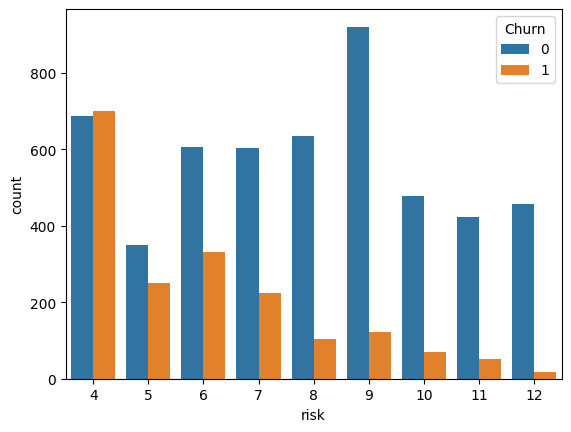

In [58]:
#Ahora categorizamos los valores por rangos
#Visualizamos la distribución de la variable de riesgo por churn
sns.countplot(data=data, x='risk', hue='Churn')


In [59]:
#Seguimos con la categoriacion de la variable 'risk'
#Utilizamos la media como referencia de los datos de 'risk' para hacer nuestra clasificación
data['TotalCharges'].describe()

,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


In [60]:
def classifier_risk(variable):
  if variable < 7:
    return('Alto riesgo')
  elif variable >= 7 and variable < 9:
    return('Riesgo regular')
  elif variable >= 9:
    return('Bajo riesgo')
  return
data['Tipo de riesgo'] = data['risk'].apply(classifier_risk)

In [61]:
#Ordenamos las nuevas variables por 'Churn', para concoer promedios

Churn
0    2555.203283
1    1531.608828
Name: LTV, dtype: float64


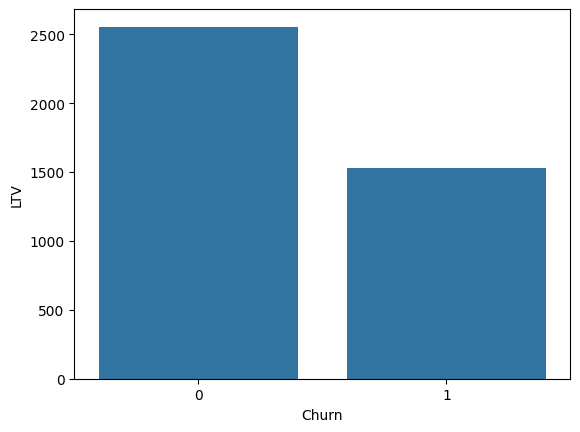

In [62]:
#Agrupamos LTV por Churn
sns.barplot(data.groupby('Churn')['LTV'].mean())
print(data.groupby('Churn')['LTV'].mean())

<Axes: xlabel='Tipo de riesgo', ylabel='count'>

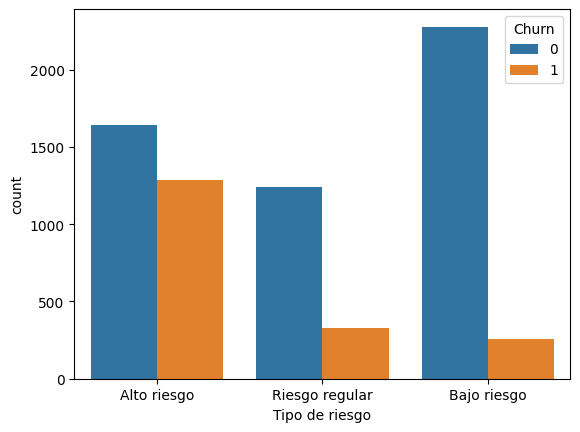

In [63]:

#Vamos a visualizar el comportamiento de nuestra variable de tipo de riesgo
sns.countplot(data = data, x = 'Tipo de riesgo', hue = 'Churn')

<Axes: xlabel='TotalServices', ylabel='LTV'>

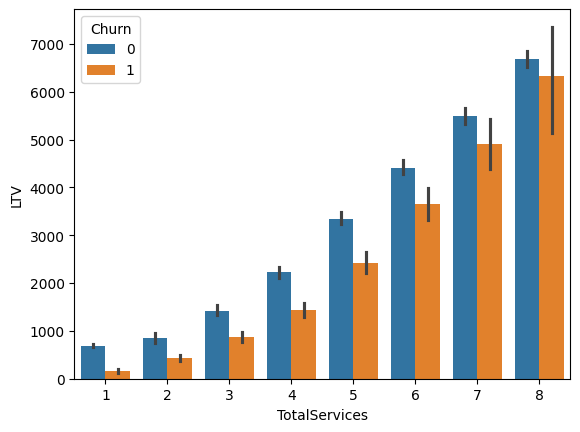

In [64]:
sns.barplot(data = data, x = 'TotalServices', y = 'LTV', hue = 'Churn')

<Axes: xlabel='Churn', ylabel='AvgMonthlySpend'>

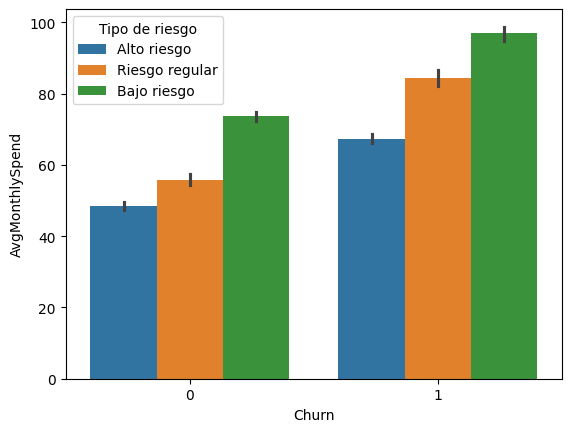

In [65]:
sns.barplot(data = data, x = 'Churn', y = 'AvgMonthlySpend', hue= 'Tipo de riesgo')

<Axes: xlabel='TotalServices', ylabel='TotalCharges'>

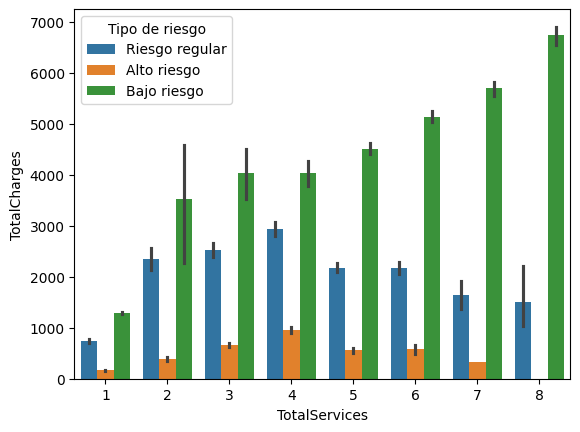

In [66]:
sns.barplot(data = data, x = 'TotalServices', y = 'TotalCharges', hue = 'Tipo de riesgo')

In [67]:
#Agrupamos por Tipo de riesgo
data.groupby('Churn')['Tipo de riesgo'].value_counts()

Churn  Tipo de riesgo
0      Bajo riesgo       2278
       Alto riesgo       1645
       Riesgo regular    1240
1      Alto riesgo       1284
       Riesgo regular     326
       Bajo riesgo        259
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='TotalServices'>

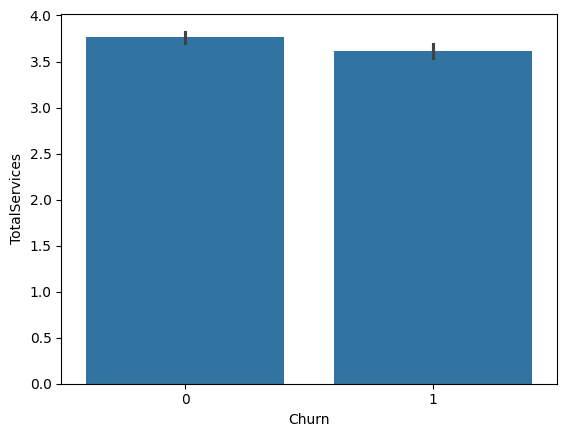

In [68]:
sns.barplot(data = data, x = 'Churn' ,y ='TotalServices')

<Axes: xlabel='level spend', ylabel='count'>

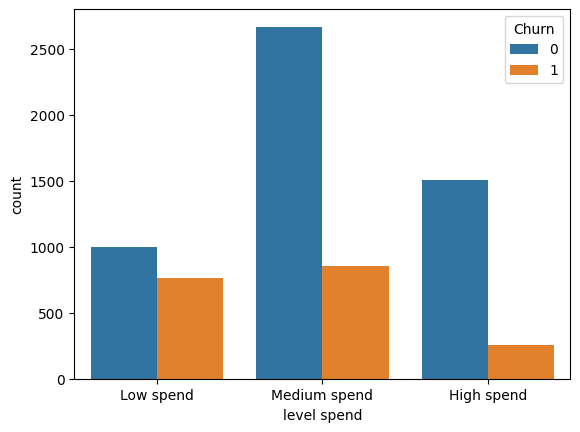

In [69]:
sns.countplot(data =data,  x='level spend' , hue= 'Churn')

<Axes: xlabel='level tenure', ylabel='count'>

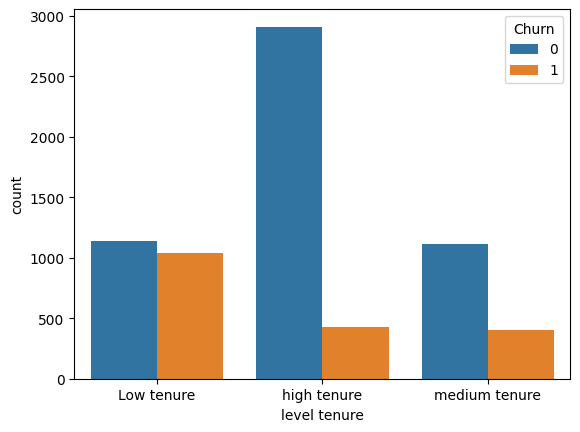

In [70]:
sns.countplot(data =data,  x='level tenure' , hue= 'Churn')

<Axes: xlabel='Contract', ylabel='count'>

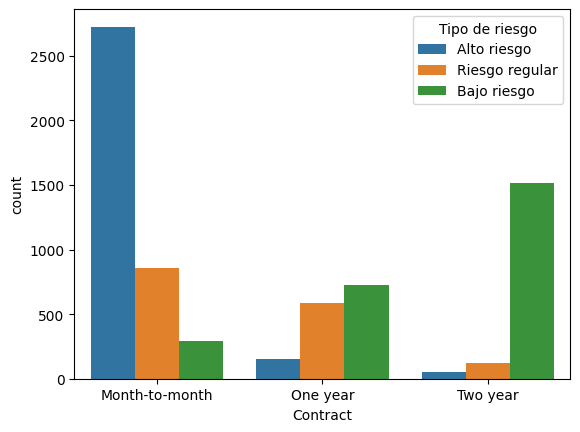

In [71]:
sns.countplot(data =data,  x='Contract', hue= 'Tipo de riesgo')

In [72]:
data.groupby(['Tipo de riesgo','Churn'])['LTV'].mean()

Tipo de riesgo  Churn
Alto riesgo     0         538.100699
                1         512.522858
Bajo riesgo     0        4368.237730
                1        5241.433398
Riesgo regular  0        1900.397863
                1        2598.056135
Name: LTV, dtype: float64

In [73]:
data.groupby('Churn')['level tenure'].value_counts()

Churn  level tenure 
0      high tenure      2909
       Low tenure       1138
       medium tenure    1116
1      Low tenure       1037
       high tenure       428
       medium tenure     404
Name: count, dtype: int64

In [74]:
data.groupby('Churn')['level spend'].value_counts()

Churn  level spend 
0      Medium spend    2666
       High spend      1503
       Low spend        994
1      Medium spend     850
       Low spend        764
       High spend       255
Name: count, dtype: int64

In [75]:
data.groupby('Churn')['TotalServices'].mean()

,TotalServices
Churn,
0,3.764478
1,3.616907


In [76]:
data.groupby('Churn')['AvgMonthlySpend'].mean()

,AvgMonthlySpend
Churn,
0,61.312024
1,74.433154


# **CONCLUSIONES FINALES **

La ingeniería de características que se llevó a cabo dentro de este conjunto de datos para conocer las variables que provocan que los consumidores tengan un alto riesgo en abandonar el servicio,  muestra que los consumidores con un LTV aproximadamente de 546, que contratan de 1 a 3 servicios, y tienen una baja permanencia de menos de 12 meses, al igual que un tipo de gasto medio total aproximadamente de 850 y un gasto promedio mensual de 74.4 considerando que cuentan con un contrato de tipo mensual, tienen más probabilidades de abandonar el servicio y aumentar la tasa de abandono.

# **FASE 4 **
Convertir tu análisis en:

Métricas claras de negocio (KPIs)

Visualizaciones ejecutivas

Un dashboard que permita tomar decisiones

In [77]:
#En esta fase vamos a crear KPI's que ayuden a conocer metricas para tomar decisiones
#KPI_1: Tasa de Churn Global
print(data['Churn'].mean() * 100)

26.578498293515356


In [78]:
#KPI_2: Número total de clientes
print(data.shape[0])

7032


In [79]:
#KPI_3: Ingreso mensual total
print(data['MonthlyCharges'].sum())

455661.0


In [80]:
#KPI_4: Ingreso perdido por churn
print(data[data['Churn'] == 1]['TotalCharges'].sum())

2862926.9


In [81]:
#KPI_5: LTV promedio
print(data['LTV'].mean())

2283.147248293515


Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


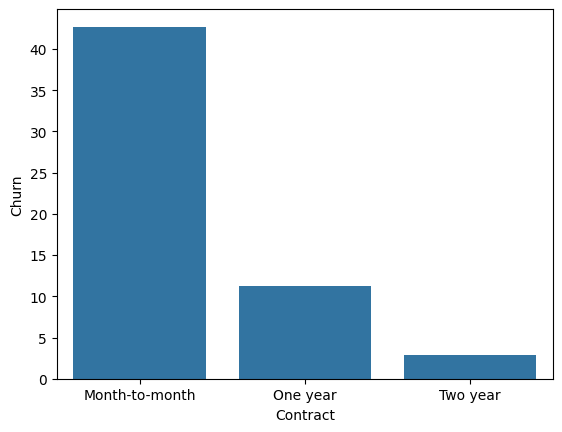

In [82]:
#KPI_6: Churn por tipo de contrato
sns.barplot(data.groupby('Contract')['Churn'].mean() * 100)
print(data.groupby('Contract')['Churn'].mean() * 100)

TotalServices
1     9.250000
2    51.581843
3    43.473896
4    34.678194
5    27.264151
6    22.060606
7    12.595420
8     5.791506
Name: Churn, dtype: float64


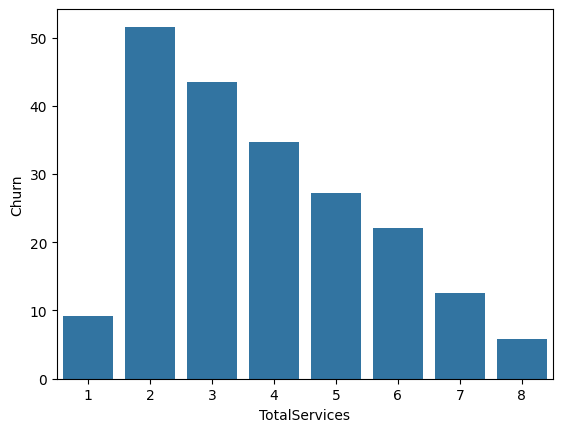

In [83]:
#KPI_7: Churn por numero de servicios
sns.barplot(data.groupby('TotalServices')['Churn'].mean() * 100)
print(data.groupby('TotalServices')['Churn'].mean() * 100)

level tenure
Low tenure       47.678161
high tenure      12.825892
medium tenure    26.578947
Name: Churn, dtype: float64


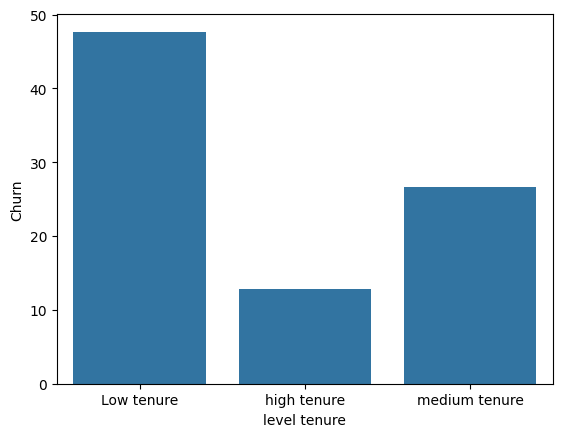

In [84]:
#KPI_8: Churn por segmento de tenure
sns.barplot(data.groupby('level tenure')['Churn'].mean() * 100)
print(data.groupby('level tenure')['Churn'].mean() * 100)

In [85]:
#Conocer quien se esta yendo por genero(gender), metodo de pago(PaymentMethod) y servicios(TotalServices)
data.groupby('Churn')['gender'].mean()


,gender
Churn,
0,0.492737
1,0.502408


In [86]:
data.groupby('Churn')['PaymentMethod'].value_counts()


Churn  PaymentMethod            
0      Mailed check                 1296
       Electronic check             1294
       Credit card (automatic)      1289
       Bank transfer (automatic)    1284
1      Electronic check             1071
       Mailed check                  308
       Bank transfer (automatic)     258
       Credit card (automatic)       232
Name: count, dtype: int64

In [87]:
data.groupby('Churn')['TotalServices'].value_counts()


Churn  TotalServices
0      1                1452
       5                 771
       4                 680
       6                 643
       3                 563
       7                 458
       2                 352
       8                 244
1      3                 433
       2                 375
       4                 361
       5                 289
       6                 182
       1                 148
       7                  66
       8                  15
Name: count, dtype: int64

<Axes: xlabel='tenure', ylabel='LTV'>

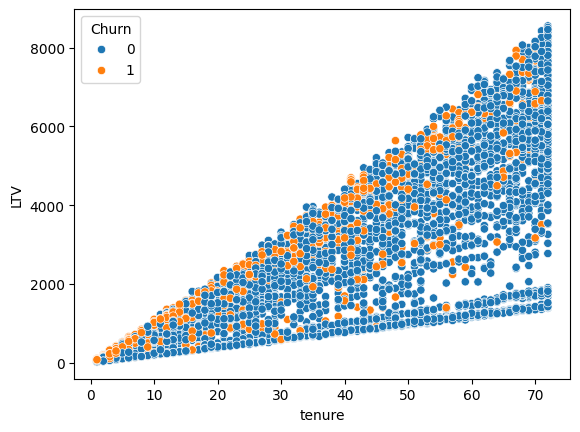

In [114]:
sns.scatterplot(data = data, x = 'tenure' ,y ='LTV', hue= 'Churn')

In [89]:
data.groupby('Churn')['level spend'].value_counts()

Churn  level spend 
0      Medium spend    2666
       High spend      1503
       Low spend        994
1      Medium spend     850
       Low spend        764
       High spend       255
Name: count, dtype: int64

In [90]:
data.groupby('Churn')['SeniorCitizen'].value_counts()

Churn  SeniorCitizen
0      0                4497
       1                 666
1      0                1393
       1                 476
Name: count, dtype: int64

In [91]:
data.groupby('Churn')['Partner'].value_counts()

Churn  Partner
0      1          2724
       0          2439
1      0          1200
       1           669
Name: count, dtype: int64

In [92]:
data.groupby('Churn')['Dependents'].value_counts()


Churn  Dependents
0      0             3390
       1             1773
1      0             1543
       1              326
Name: count, dtype: int64

<Axes: xlabel='tenure', ylabel='AvgMonthlySpend'>

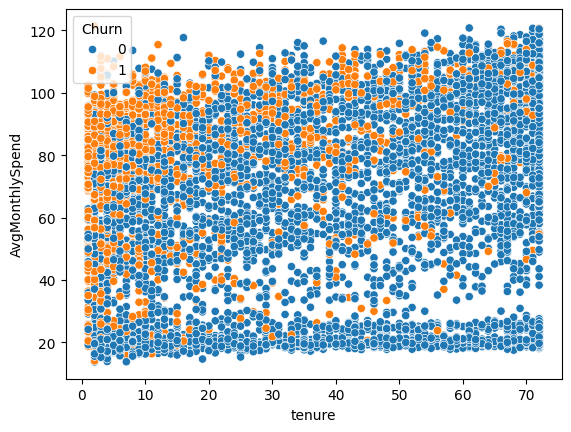

In [93]:
sns.scatterplot(data= data ,x='tenure' , y ='AvgMonthlySpend', hue = 'Churn')

In [94]:
data.groupby('Churn')['PhoneService'].value_counts()

Churn  PhoneService
0      1               4653
       0                510
1      1               1699
       0                170
Name: count, dtype: int64

In [95]:
data.groupby('Churn')['OnlineSecurity'].value_counts()

Churn  OnlineSecurity     
0      0                      2036
       1                      1720
       No internet service    1407
1      0                      1461
       1                       295
       No internet service     113
Name: count, dtype: int64

In [96]:
data.groupby('Churn')['OnlineBackup'].value_counts()

Churn  OnlineBackup       
0      1                      1902
       0                      1854
       No internet service    1407
1      0                      1233
       1                       523
       No internet service     113
Name: count, dtype: int64

In [97]:
data.groupby('Churn')['DeviceProtection'].value_counts()

Churn  DeviceProtection   
0      0                      1883
       1                      1873
       No internet service    1407
1      0                      1211
       1                       545
       No internet service     113
Name: count, dtype: int64

In [98]:
data.groupby('Churn')[
'TechSupport'].value_counts()

Churn  TechSupport        
0      0                      2026
       1                      1730
       No internet service    1407
1      0                      1446
       1                       310
       No internet service     113
Name: count, dtype: int64

In [99]:
data.groupby('Churn')[
'StreamingTV'].value_counts()

Churn  StreamingTV        
0      1                      1889
       0                      1867
       No internet service    1407
1      0                       942
       1                       814
       No internet service     113
Name: count, dtype: int64

In [100]:
data.groupby('Churn')[
'StreamingMovies'].value_counts()

Churn  StreamingMovies    
0      1                      1913
       0                      1843
       No internet service    1407
1      0                       938
       1                       818
       No internet service     113
Name: count, dtype: int64

In [101]:
data.groupby('Churn')[
'InternetService_DSL'].mean() * 100

,InternetService_DSL
Churn,
0,37.904319
1,24.558587


In [102]:
data.groupby('Churn')['InternetService_Fiber optic'].mean() * 100

,InternetService_Fiber optic
Churn,
0,34.844083
1,69.395399


In [103]:
e = data[(data['TotalServices'] >= 2) & (data['TotalServices']<= 4)]

<Axes: xlabel='TotalServices', ylabel='Churn'>

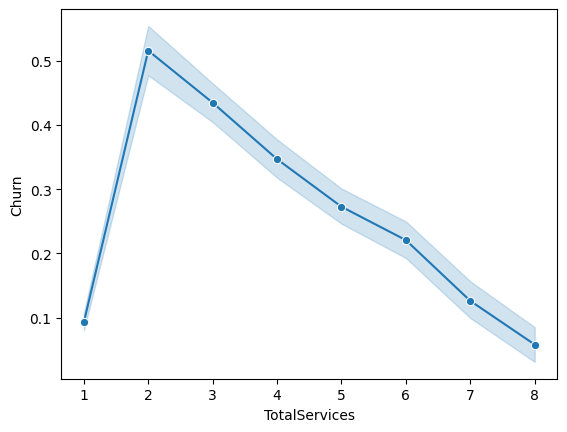

In [104]:
sns.lineplot(data= data, x ='TotalServices', y= 'Churn',marker='o')

In [105]:
data.to_csv('telco_cleaned.csv', index=False)